# ***BASELINE MODELS***

### **A baseline model is a trivial solution to our problem. It often uses heuristics,or simple statistics, to generate predictions. The baseline model is the simplest solution you can think of—it should not require any training, and the cost of implementation should be very low.**

## ***---1---Forecasting the historical mean-----***
### *we are going to work with the quarterly EPS in US dollars (USD) of Johnson & Johnson from 1960 to 1980. Our goal is to use the data from 1960 to the end of 1979 to predict the four quarters of 1980. The first baseline we’ll discuss uses the historical mean, which is the arithmetic mean of past values. Its implementation is straightforward: calculate the mean of the training set, and it will be our prediction for the four quarters of 1980*

In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None

In [228]:
df = pd.read_csv('jj_eps_formatted.csv',index_col=0)
print(df.head())

         date  data
0  1960-01-01  0.71
1  1960-04-01  0.63
2  1960-07-02  0.85
3  1960-10-01  0.44
4  1961-01-01  0.61


### *The first five entries of quarterly earnings per share for the Johnson & Johnson dataset. Notice how our DataFrame has two columns: date and data. It also has row indices starting at 0.*

In [229]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [230]:
# splitting the data into train and testing
train=df[:-4]
test=df[-4:]

### ***Implementing the historical mean baseline***

In [231]:
# Now we are ready to implement our baseline. We will first use the arithmetic mean of the entire train set.
historical_mean=np.mean(train['data'])
print(historical_mean)

4.3085


In [232]:
# Now we will naively forecast this value for each quarter of 1980. To do so, we’ll simply create a new column, pred_mean, that holds the historical mean of the training set as a forecast:
test.loc[:, 'pred_mean'] = historical_mean 

### ***Next, we need to define and calculate an error metric in order to evaluate the performance of our forecasts on the test set. In this case, we will use the mean absolute percentage error (MAPE). It is a measure of prediction accuracy for forecasting methods that is easy to interpret and independent of the scale of our data. This means that whether we are working with two-digit values or six-digit values, the MAPE will always be expressed as a percentage. Thus, the MAPE returns the percentage of how much the forecast values deviate from the observed or actual values on average,whether the prediction was higher or lower than the observed values. The MAPE.**
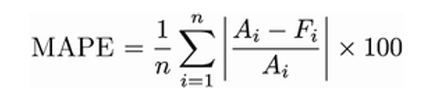

# **Ai is the actual value at point i in time, and Fi is the forecast value at point i in time; n is simply the number of forecasts. In our case,because we are forecasting the four quarters of 1980, n = 4**

# Inside the summation, the forecast value is subtracted from the actual value, and that result is divided by the actual value, which gives us the percentage error. Then we take the absolute value of the percentage error. This operation is repeated for each of the n points in time, and the results are added together.Finally, we divide the sum by n, the number of points in time, which effectively gives us the mean absolute percentage error.

In [233]:
# We’ll define a mape function that takes in two vectors: y_true for the actual values observed in the test set and y_pred for the forecast values.
def mape(y_true , y_pred):
    return np.mean(np.abs(y_true - y_pred)/y_true)*100

In [234]:
# Now we can calculate the MAPE of our baseline. Our actual values are in the data column of test, so it will be the first parameter passed to the mape function. Our forecasts are in the pred_mean column of test, so it will be our second parameter for the function
mape_hist_mean=mape(test['data'],test['pred_mean'])
print(mape_hist_mean)

70.00752571263575


### the function gives a MAPE of 70.00%. This means that our baseline deviates by 70% on average from the observed quarterly EPS of Johnson & Johnson in 1980

## ***----Visualizing our forecasts----***

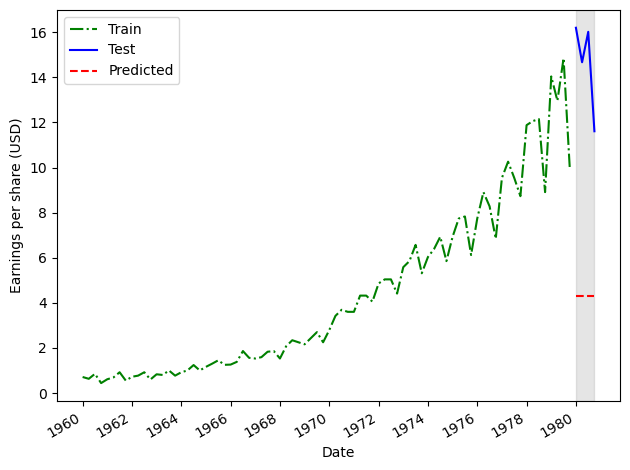

In [235]:
fig, ax = plt.subplots() 
#fig = whole graph window,(fig=notbook page)
#ax = plotting area inside the graph,(chart drawn on page)
ax.plot(train['date'], train['data'], 'g-.', label='Train')# Plotting Training Data
# g=green, "-."=dash-dot line , Label="train" 
ax.plot(test['date'], test['data'], 'b-', label='Test') # Plotting Training Data
# b = blue , "-"= solid line
ax.plot(test['date'], test['pred_mean'], 'r--', label='Predicted') # Predicted plot values
# r= red, "--"=dashed line
ax.set_xlabel('Date') 
ax.set_ylabel('Earnings per share (USD)') 
# Label X and Y Axis Makes graph understandable.
ax.axvspan(80, 83, color='#808080', alpha=0.2) # Highlight Forecast Horizon
# This draws shaded rectangle from index 80 to 83.
ax.legend(loc=2) # shows label green=train,blue=test,red=predicted, loc=2 means top-lefr corner
  
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980]) # Set Custom X-axis Labels
fig.autofmt_xdate() # rotates dates if needed
plt.tight_layout() # tight_layout()

### Predicting the historical mean as a baseline. You can see that the prediction is far from the actual values in the test set. This baseline gives a MAPE of 70%.

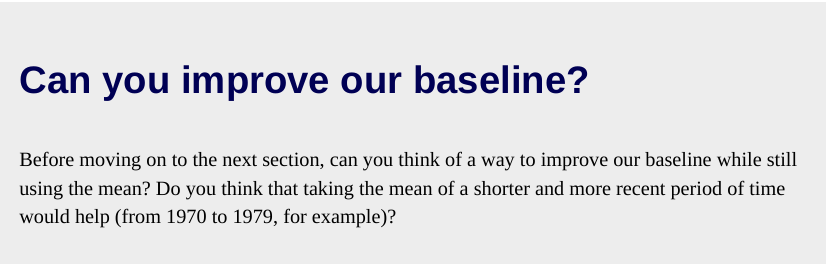

### ---------------------------------------------------------------------------------------------------

## ***---2---Forecasting last year’s mean-----***

### The lesson learned from the previous baseline is that earlier values do not seem to be predictive of future values in the long term because of the positive trend component in our dataset. Earlier values seem to be too small to be representative of the new level the EPS reaches toward the end of 1979 and onwards into 1980.

### **What if we use the mean of the last year in our training set to forecast the following year.**

In [236]:
#  calculate the mean of the last year in the train set.
last_year_mean = np.mean(train.data[-4:])     
print(last_year_mean)

12.96


In [237]:
#  we’ll create a new pred_last_yr_mean column to hold the mean of last year as our predictions
test.loc[:, 'pred_last_yr_mean']=last_year_mean

In [238]:
# using MAPE function again 
mape_last_year_mean=mape(test['data'],test['pred_last_yr_mean'])
print(mape_last_year_mean)
# This gives us a MAPE of 15.60%

15.5963680725103


## ***----Visualizing our forecasts----***

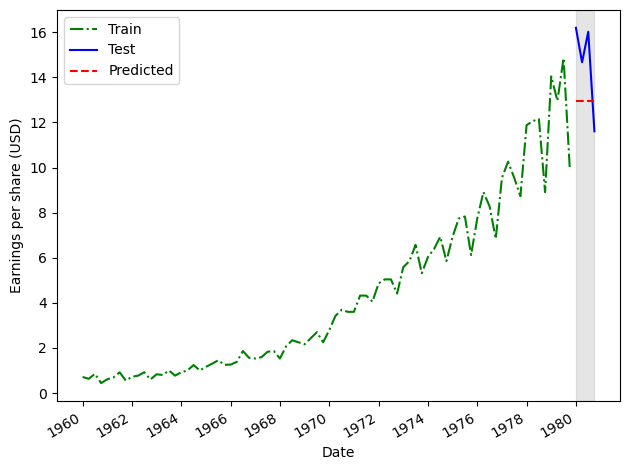

In [239]:
fig, ax = plt.subplots() 
#fig = whole graph window,(fig=notbook page)
#ax = plotting area inside the graph,(chart drawn on page)
ax.plot(train['date'], train['data'], 'g-.', label='Train')# Plotting Training Data
# g=green, "-."=dash-dot line , Label="train" 
ax.plot(test['date'], test['data'], 'b-', label='Test') # Plotting Training Data
# b = blue , "-"= solid line
ax.plot(test['date'], test['pred_last_yr_mean'], 'r--', label='Predicted') # Predicted plot values
# r= red, "--"=dashed line
ax.set_xlabel('Date') 
ax.set_ylabel('Earnings per share (USD)') 
# Label X and Y Axis Makes graph understandable.
ax.axvspan(80, 83, color='#808080', alpha=0.2) # Highlight Forecast Horizon
# This draws shaded rectangle from index 80 to 83.
ax.legend(loc=2) # shows label green=train,blue=test,red=predicted, loc=2 means top-lefr corner
  
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980]) # Set Custom X-axis Labels
fig.autofmt_xdate() # rotates dates if needed
plt.tight_layout() # tight_layout()

### ***Predicting the mean of the last year in the training set (1979) as a baseline model. You can see that the prediction is closer to the actual values of the test set when compared to the previous baseline thatmwe built.***

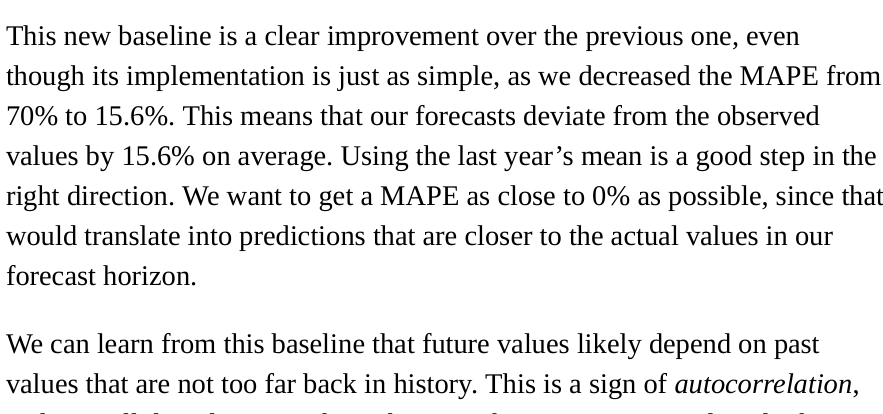

#### let’s look at another baseline that we could develop for this situation

# ---------------------------------------------------------------------------------

## ***---3---Predicting using the last known value-----***

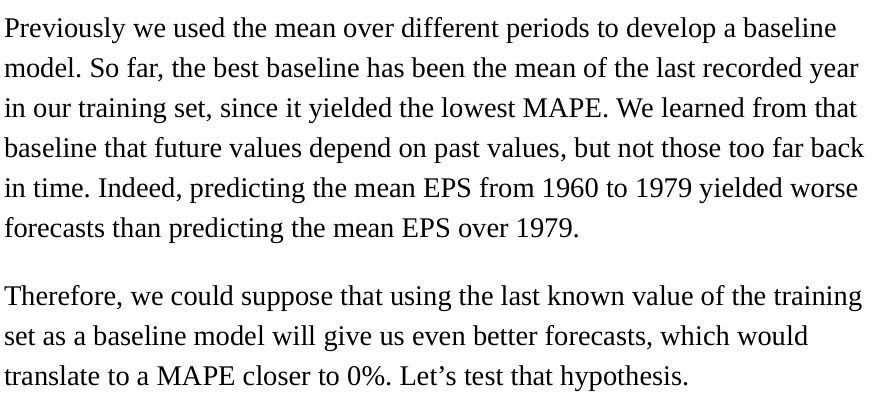

In [240]:
# extracting the last value of the training set
last=train.data.iloc[-1]
print(last)

9.99


In [241]:
# Again, we’ll append a new column called pred_last to hold the predictions.
test.loc[:,'pred_last']=last

In [242]:
# Again using MAPE function
mape_last=mape(test['data'],test['pred_last'])
print(mape_last)

30.457277908606535


## ***----Visualizing our forecasts Again----***

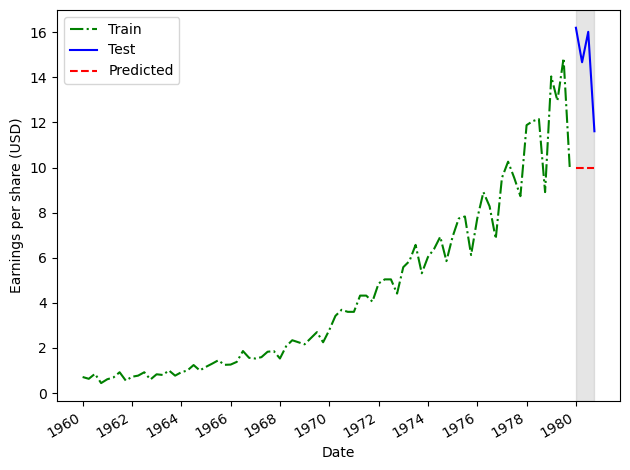

In [243]:
fig, ax = plt.subplots() 
#fig = whole graph window,(fig=notbook page)
#ax = plotting area inside the graph,(chart drawn on page)
ax.plot(train['date'], train['data'], 'g-.', label='Train')# Plotting Training Data
# g=green, "-."=dash-dot line , Label="train" 
ax.plot(test['date'], test['data'], 'b-', label='Test') # Plotting Training Data
# b = blue , "-"= solid line
ax.plot(test['date'], test['pred_last'], 'r--', label='Predicted') # Predicted plot values
# r= red, "--"=dashed line
ax.set_xlabel('Date') 
ax.set_ylabel('Earnings per share (USD)') 
# Label X and Y Axis Makes graph understandable.
ax.axvspan(80, 83, color='#808080', alpha=0.2) # Highlight Forecast Horizon
# This draws shaded rectangle from index 80 to 83.
ax.legend(loc=2) # shows label green=train,blue=test,red=predicted, loc=2 means top-lefr corner
  
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980]) # Set Custom X-axis Labels
fig.autofmt_xdate() # rotates dates if needed
plt.tight_layout() # tight_layout()

## ***Predicting the last known value of the train set as a baseline model. We can see that this baseline, with a MAPE of 30.45%, is better than our first baseline, but less performant than our second one.***

### It seems that our new hypothesis did not improve upon the last baseline that we built, since we have a MAPE of 30.45%, whereas we achieved a MAPE of 15.60% using the mean EPS over 1979. Therefore, these new forecasts are farther from the observed values in 1980.

# ------------------------------------------------------------------------------

## ***---4---Implementing the naive seasonal forecaste-----***

We considered the trend component for the first two baselines.but we have not studied another important component from our dataset,which is the seasonal component, There are clear cyclical patterns in our data, and that is a piece of information that we
could use to construct one last baseline: the naive seasonal forecast.


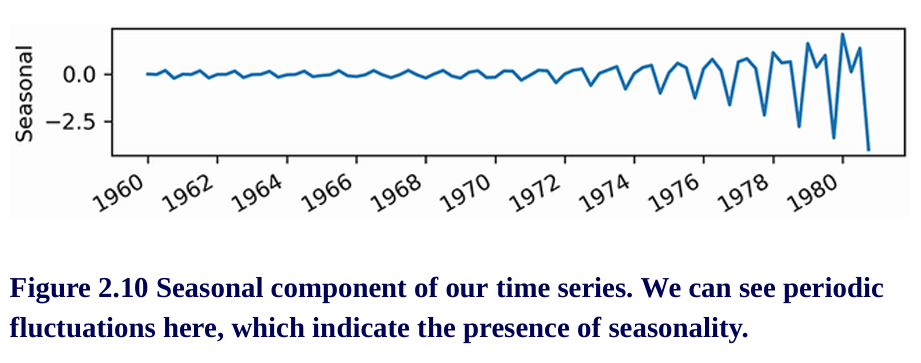

The naive seasonal forecast takes the last observed cycle and repeats it into the future. In our case, a full cycle occurs in four quarters, so we will take
the EPS from the first quarter of 1979 and predict that value for the first quarter of 1980. Then we’ll take the EPS from the second quarter of 1979 and predict that value for the second quarter of 1980. This process will be repeated for the third and fourth quarters.

In [244]:
#  we can implement this baseline by simply taking the last fourvalues of the train set, which correspond to the four quarters of 1979, and assigning them to the corresponding quarters in 1980
test.loc[:, 'pred_last_season']=train['data'][-4:].values

In [245]:
# Again calculating the MAPE
mape_naive_seasonal=mape(test['data'],test['pred_last_season'])
print(mape_naive_seasonal)
# This gives us a MAPE of 11.56%, which is the lowest MAPE from all the baselines in this chapter

11.561658552433654


## ***----Visualizing our forecasts Again----***

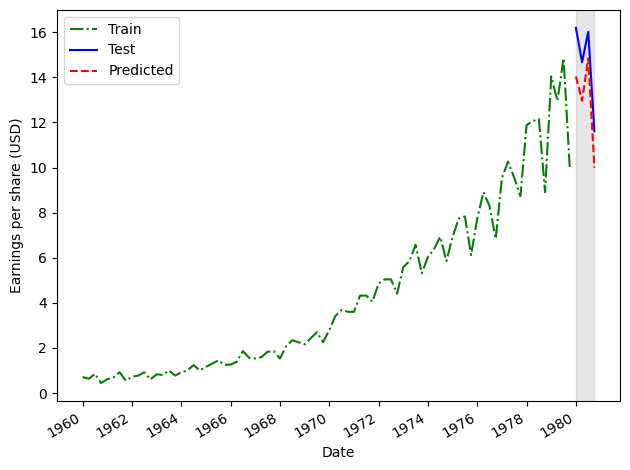

In [246]:
fig, ax = plt.subplots() 
#fig = whole graph window,(fig=notbook page)
#ax = plotting area inside the graph,(chart drawn on page)
ax.plot(train['date'], train['data'], 'g-.', label='Train')# Plotting Training Data
# g=green, "-."=dash-dot line , Label="train" 
ax.plot(test['date'], test['data'], 'b-', label='Test') # Plotting Training Data
# b = blue , "-"= solid line
ax.plot(test['date'], test['pred_last_season'], 'r--', label='Predicted') # Predicted plot values
# r= red, "--"=dashed line
ax.set_xlabel('Date') 
ax.set_ylabel('Earnings per share (USD)') 
# Label X and Y Axis Makes graph understandable.
ax.axvspan(80, 83, color='#808080', alpha=0.2) # Highlight Forecast Horizon
# This draws shaded rectangle from index 80 to 83.
ax.legend(loc=2) # shows label green=train,blue=test,red=predicted, loc=2 means top-lefr corner
  
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980]) # Set Custom X-axis Labels
fig.autofmt_xdate() # rotates dates if needed
plt.tight_layout() # tight_layout()

## ***Result of the naive seasonal forecast on the test set. This forecast is more similar to the data observed in the test set, and it resulted in the lowest MAPE. Clearly, the seasonality of this dataset has an impact on future values, and it must be considered when forecasting.***

# ***CONCLUSION*** - **we developed four different baselines for our forecasting project. We used the arithmetic mean of the entire training set, the mean of the last year in the train set, the last known value of the train set, and a naive seasonal forecast. Each baseline was then evaluated on a test set using the MAPE metric. Figure summarizes the MAPE of each baseline we developed in this chapter. As you can see, the baseline using the naive seasonal forecast has the lowest MAPE, and therefore the best performance.**


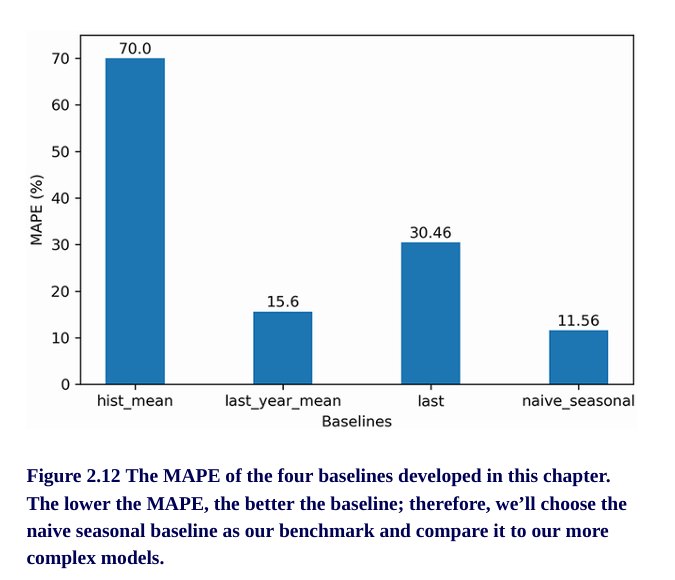

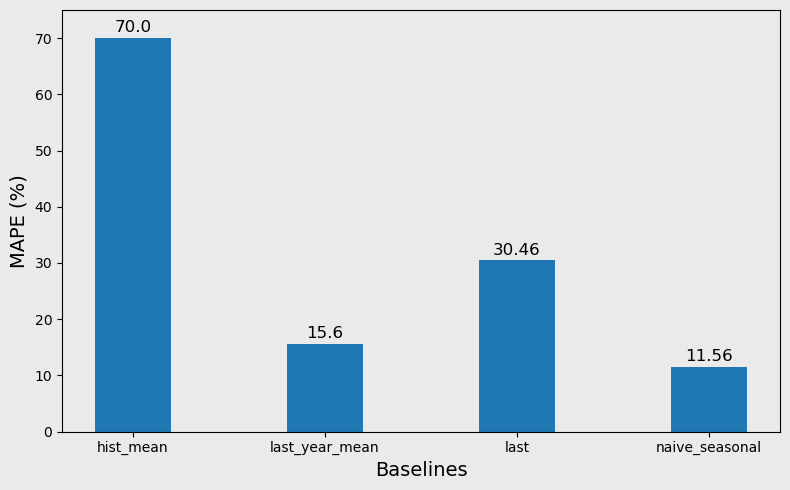

In [248]:
import matplotlib.pyplot as plt

# Data
x = ['hist_mean', 'last_year_mean', 'last', 'naive_seasonal']
y = [70.00, 15.60, 30.46, 11.56]

# Figure size
fig, ax = plt.subplots(figsize=(8,5))

# Background color
fig.patch.set_facecolor('#eaeaea')
ax.set_facecolor('#eaeaea')

# Bar plot
bars = ax.bar(x, y, width=0.4, color='#1f77b4')

# Labels
ax.set_xlabel('Baselines', fontsize=14)
ax.set_ylabel('MAPE (%)', fontsize=14)

# Y limit
ax.set_ylim(0, 75)

# Value labels on top
for index, value in enumerate(y):
    ax.text(index, value + 1, str(value),
            ha='center', fontsize=12)

# Layout
plt.tight_layout()

# Save image
plt.savefig('barplot.png', dpi=300)

# Show plot
plt.show()